# LambdaLLG 1D Quickstart

This notebook runs a minimal 1D Landau-Lifshitz-Gilbert simulation and
shows how to extract average magnetization over time.


In [2]:
using Pkg; Pkg.activate("../")

  Activating project at `/mnt/graphene/home/freyes/MyCode/test/LambdaLLG.jl`


In [3]:
using LambdaLLG
using Random
using Statistics
using LinearAlgebra

Random.seed!(1)


[ Info: Precompiling LambdaLLG [e49eaffb-1ff4-4058-b8bd-8b5ecf266929] (cache misses: wrong source (4))


TaskLocalRNG()

## 1. Define model parameters

`LLGParams1D(Nx, J, K, B, αG)` sets the chain size and physical terms.


In [9]:
Nx = 32
J = 1.0
K = (0.0, 0.0, -0.02)
B = (0.0, 0.0, -0.10)
αG = 0.05

p = LLGParams1D(Nx, J, K, B, αG);

## 2. Build a unit-spin initial state

We start from a weakly tilted random azimuthal configuration.


In [5]:
s0 = zeros(3, Nx)
for i in 1:Nx
    θ = 0.25
    ϕ = 2pi * rand()
    s0[:, i] .= (sin(θ) * cos(ϕ), sin(θ) * sin(ϕ), cos(θ))
end

## 3. Integrate the dynamics


In [6]:
tspan = (0.0, 40.0)
sol = evolve1D(s0, tspan, p)

(length(sol.t), sol.t[1], sol.t[end])

(471, 0.0, 40.0)

## 4. Post-process results

- `mz` is the average z-magnetization.
- `format_results(sol)` returns `[time | flattened_state...]`.


In [7]:
mz = [mean(reshape(u, 3, Nx)[3, :]) for u in sol.u]
data = format_results(sol)

(size(data), mz[end])

((471, 97), 0.9956895100990809)

## 5. Optional plot

This cell draws a figure if `PyPlot` is installed.


[ Info: Precompiling SciMLBasePyCallExt [d083c4ab-32a5-5342-b289-e118b48fb79d] (cache misses: wrong dep version loaded (4))


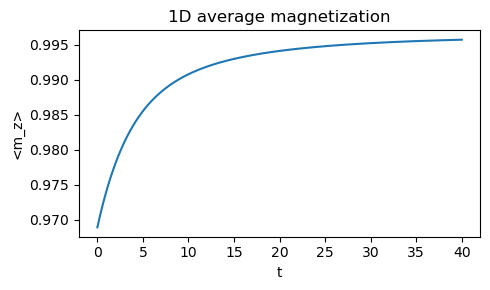

In [8]:
import PyPlot as plt

plt.figure(figsize=(5, 3))
plt.plot(sol.t, mz)
plt.xlabel("t")
plt.ylabel("<m_z>")
plt.title("1D average magnetization")
plt.tight_layout()